# SVI vs MCMC Accuracy Comparison

In [1]:
# Disable FutureWarnings for cleaner output
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Path setup to access privugger code
import os, sys
sys.path.append(os.path.join("../../../"))

# Import standard libraries
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd
from scipy.stats import norm, entropy, wasserstein_distance
from scipy.special import kl_div

# Configure matplotlib
plt.rcParams["figure.autolayout"] = True
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

# Import privugger
import privugger as pv

## Define DP Gaussian Average Mechanism

In [2]:
def dp_gaussian_average(dataset, max_value, min_value, delta, epsilon):
    """Differentially private average using Gaussian mechanism"""
    avg = sum(dataset) / len(dataset)
    sensitivity = (max_value - min_value) / len(dataset)
    noise_std = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    noise = np.random.normal(loc=0, scale=noise_std)
    return avg + noise

## Generate Synthetic Dataset

In [3]:
# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset
N = 50 
true_mean = 5.0
data_std = 1.0
min_value = 0.0
max_value = 10.0

# Generate data bounded between min_value and max_value
raw_data = np.random.normal(true_mean, data_std, N)
data = np.clip(raw_data, min_value, max_value)

# DP parameters
epsilon = 1.0
delta = 0.01

# Calculate the true DP output (what we'll observe)
sensitivity = (max_value - min_value) / N
noise_std = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
true_avg = np.mean(data)

# Generate the observed output with added noise
np.random.seed(123)  # Fix seed for reproducible noise
observed_output = dp_gaussian_average(data, max_value, min_value, delta, epsilon)

print(f"Dataset: {data}")
print(f"True average: {true_avg:.4f}")
print(f"DP output: {observed_output:.4f}")
print(f"Noise std: {noise_std:.4f}")

Dataset: [5.49671415 4.8617357  5.64768854 6.52302986 4.76584663 4.76586304
 6.57921282 5.76743473 4.53052561 5.54256004 4.53658231 4.53427025
 5.24196227 3.08671976 3.27508217 4.43771247 3.98716888 5.31424733
 4.09197592 3.5876963  6.46564877 4.7742237  5.0675282  3.57525181
 4.45561728 5.11092259 3.84900642 5.37569802 4.39936131 4.70830625
 4.39829339 6.85227818 4.98650278 3.94228907 5.82254491 3.77915635
 5.2088636  3.04032988 3.67181395 5.19686124 5.73846658 5.17136828
 4.88435172 4.6988963  3.52147801 4.28015579 4.53936123 6.05712223
 5.34361829 3.23695984]
True average: 4.7745
DP output: 4.0998
Noise std: 0.6215


## Set Up Privugger Program

In [4]:
# Define input specifications
# We'll use a normal distribution for dataset entries with true_mean and data_std
dataset_spec = pv.Normal("dataset", mu=true_mean, std=data_std, num_elements=N)

# Setup privugger dataset and program
ds = pv.Dataset(input_specs=[dataset_spec])

def dp_gaussian_average_wrapper(dataset):
    """Wrapper with inline implementation instead of calling another function"""
    # Hard-code your parameter values here
    max_value = 10.0  # Your max value
    min_value = 0.0   # Your min value
    delta = 0.01      # Your delta
    epsilon = 1.0     # Your epsilon
    
    # Direct implementation (copied from dp_gaussian_average)
    avg = sum(dataset) / len(dataset)
    sensitivity = (max_value - min_value) / len(dataset)
    noise_std = sensitivity * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    noise = np.random.normal(loc=0, scale=noise_std)
    return avg + noise

# Create the program with our DP function
program = pv.Program('output',
                    dataset=ds,
                    output_type=pv.Float,
                    function=dp_gaussian_average_wrapper)

# Add the observation constraint to the program
program.add_observation(f'output=={observed_output}', precision=0.01)

## True Posterior (Analytical Solution)

For the simple Gaussian average mechanism, we can calculate the true posterior analytically.

In [5]:
def calculate_true_posterior(observed, data_std, noise_std, n_samples=10000):
    """Calculate the true posterior for a simple Gaussian mechanism"""
    # Prior variance for the mean (based on data variance divided by n)
    prior_var = (data_std**2) / N
    
    # Likelihood variance (noise variance)
    likelihood_var = noise_std**2
    
    # Posterior precision is sum of prior and likelihood precisions
    posterior_precision = (1 / prior_var) + (1 / likelihood_var)
    posterior_var = 1 / posterior_precision
    
    # Posterior mean is weighted average of prior mean and observed value
    posterior_mean = ((true_mean / prior_var) + (observed / likelihood_var)) * posterior_var
    
    # Generate samples from the true posterior
    true_posterior_samples = np.random.normal(posterior_mean, np.sqrt(posterior_var), n_samples)
    
    return {
        'posterior_mean': posterior_mean,
        'posterior_std': np.sqrt(posterior_var),
        'samples': true_posterior_samples
    }

# Calculate the true posterior
true_posterior = calculate_true_posterior(observed_output, data_std, noise_std)

print(f"True posterior mean: {true_posterior['posterior_mean']:.4f}")
print(f"True posterior std: {true_posterior['posterior_std']:.4f}")

True posterior mean: 4.9557
True posterior std: 0.1379


## Run MCMC Inference

In [6]:
# Run MCMC inference using PyMC3
print("Running MCMC inference with PyMC3...")
start_time_mcmc = time.time()
mcmc_trace = pv.infer(program, cores=4, draws=5000, method='pymc3', return_model=False)
mcmc_time = time.time() - start_time_mcmc
print(f"MCMC inference completed in {mcmc_time:.2f} seconds")

# Extract posterior samples for dataset mean
mcmc_samples = mcmc_trace.posterior['dataset'].values.reshape(-1, N)
mcmc_means = mcmc_samples.mean(axis=1)

# Calculate summary statistics
mcmc_mean = np.mean(mcmc_means)
mcmc_std = np.std(mcmc_means)

print(f"MCMC posterior mean: {mcmc_mean:.4f}")
print(f"MCMC posterior std: {mcmc_std:.4f}")

Running MCMC inference with PyMC3...


Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [dataset]


Output()

/home/tommy/miniconda3/envs/privugger/lib/python3.12/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/home/tommy/miniconda3/envs/privugger/lib/python3.12/site-packages/pymc/step_methods/metropolis.py:285: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 15 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


MCMC inference completed in 17.11 seconds
MCMC posterior mean: 4.1501
MCMC posterior std: 0.7419


## Run SVI Inference

In [7]:
# Run SVI inference using Pyro
print("Running SVI inference with Pyro...")
start_time_svi = time.time()
svi_trace = pv.infer(program, cores=4, draws=10000, method='pyro', return_model=False, svi_steps=2000, svi_lr="auto")
svi_time = time.time() - start_time_svi
print(f"SVI inference completed in {svi_time:.2f} seconds")

# Extract posterior samples for dataset mean
svi_samples = svi_trace.posterior['dataset'].values.reshape(-1, N)
svi_means = svi_samples.mean(axis=1)

# Calculate summary statistics
svi_mean = np.mean(svi_means)
svi_std = np.std(svi_means)

print(f"SVI posterior mean: {svi_mean:.4f}")
print(f"SVI posterior std: {svi_std:.4f}")

/home/tommy/Documents/Thesis/privugger/docs/tutorials/pyro_svi/../../../privugger/inference/inference.py:85: UserWarning: The following parameters are not used by the 'pyro' backend: 'cores' (value: 4)
  warnings.warn(


Running SVI inference with Pyro...
Observations detected, running SVI with 4000 steps
[run_svi] Using automatic LR scheduling: start_lr=0.001, gamma=0.99


TypeError: ClippedAdam() got an unexpected keyword argument 'lr'

## Compare Posterior Distributions

True posterior samples: 10000
MCMC samples: 10000
SVI samples: 10000


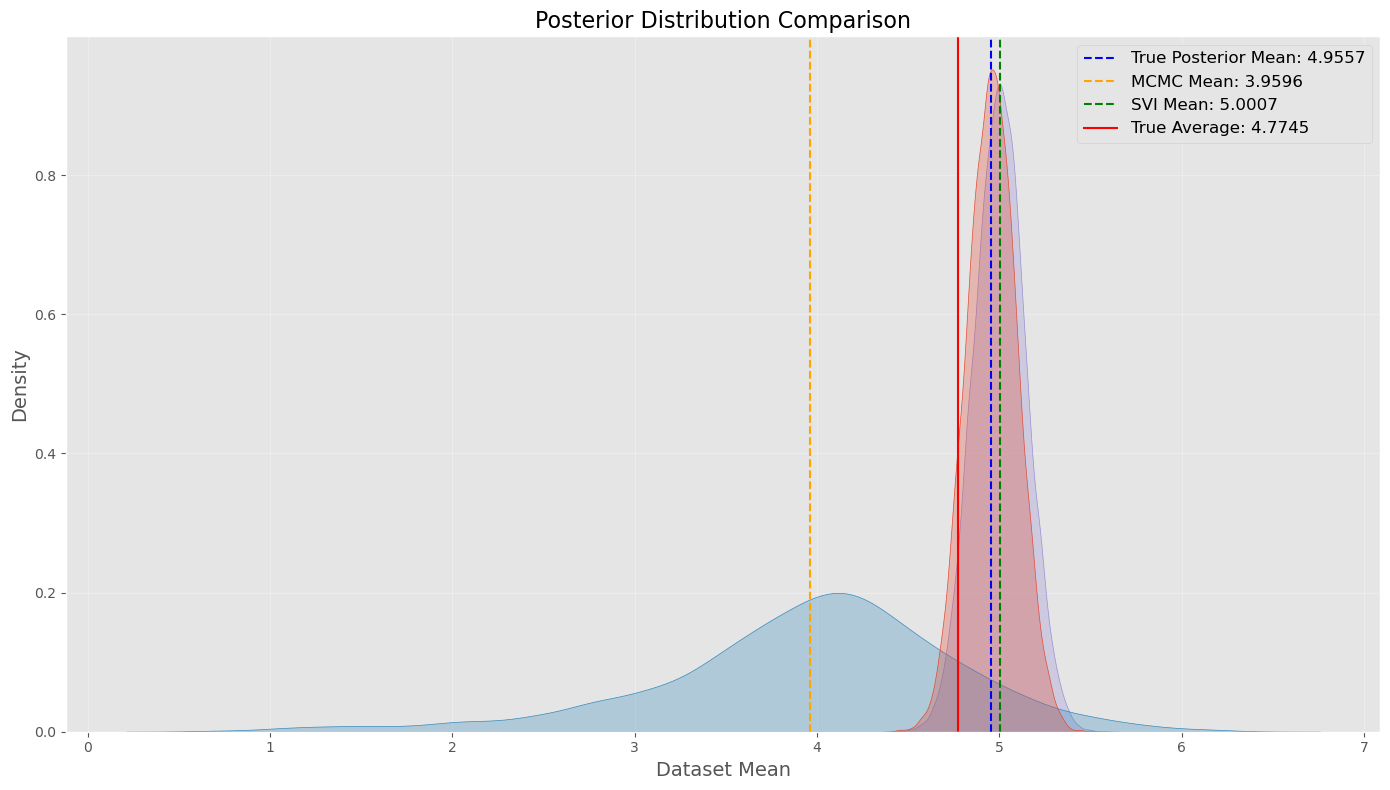

In [ ]:
# First, check the lengths of each array
true_len = len(true_posterior['samples'])
mcmc_len = len(mcmc_means) if 'mcmc_means' in locals() else 0
svi_len = len(svi_means) if 'svi_means' in locals() else 0

print(f"True posterior samples: {true_len}")
print(f"MCMC samples: {mcmc_len}")
print(f"SVI samples: {svi_len}")
# Create comparison dataframe for easier plotting
comparison_df = pd.DataFrame({
    'True Posterior': true_posterior['samples'],
    'MCMC': mcmc_means,
    'SVI': svi_means
})

# Plot posterior distributions
plt.figure(figsize=(14, 8))
sns.kdeplot(data=comparison_df, fill=True, alpha=0.3)

# Add vertical lines for the means
plt.axvline(true_posterior['posterior_mean'], color='blue', linestyle='--', 
           label=f'True Posterior Mean: {true_posterior["posterior_mean"]:.4f}')
plt.axvline(mcmc_mean, color='orange', linestyle='--', 
           label=f'MCMC Mean: {mcmc_mean:.4f}')
plt.axvline(svi_mean, color='green', linestyle='--', 
           label=f'SVI Mean: {svi_mean:.4f}')

# Add true value
plt.axvline(true_avg, color='red', linestyle='-', 
           label=f'True Average: {true_avg:.4f}')

plt.title('Posterior Distribution Comparison', fontsize=16)
plt.xlabel('Dataset Mean', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Calculate Accuracy Metrics

In [ ]:
def calculate_accuracy_metrics(true_samples, mcmc_samples, svi_samples, bins=50):
    """Calculate various accuracy metrics for the posterior distributions"""
    
    # Create histograms for all three distributions
    hist_range = (min([true_samples.min(), mcmc_samples.min(), svi_samples.min()]),
                 max([true_samples.max(), mcmc_samples.max(), svi_samples.max()]))
    
    true_hist, bin_edges = np.histogram(true_samples, bins=bins, range=hist_range, density=True)
    mcmc_hist, _ = np.histogram(mcmc_samples, bins=bins, range=hist_range, density=True)
    svi_hist, _ = np.histogram(svi_samples, bins=bins, range=hist_range, density=True)
    
    # Add small epsilon to avoid division by zero
    epsilon = 1e-10
    true_hist = true_hist + epsilon
    mcmc_hist = mcmc_hist + epsilon
    svi_hist = svi_hist + epsilon
    
    # Normalize histograms
    true_hist = true_hist / true_hist.sum()
    mcmc_hist = mcmc_hist / mcmc_hist.sum()
    svi_hist = svi_hist / svi_hist.sum()
    
    # Calculate KL divergence: KL(True || Method)
    kl_mcmc = entropy(true_hist, mcmc_hist)
    kl_svi = entropy(true_hist, svi_hist)
    
    # Calculate Wasserstein distance (Earth Mover's Distance)
    w_mcmc = wasserstein_distance(true_samples, mcmc_samples)
    w_svi = wasserstein_distance(true_samples, svi_samples)
    
    # Calculate absolute error in mean and std
    true_mean = np.mean(true_samples)
    true_std = np.std(true_samples)
    
    mean_error_mcmc = abs(np.mean(mcmc_samples) - true_mean)
    std_error_mcmc = abs(np.std(mcmc_samples) - true_std)
    
    mean_error_svi = abs(np.mean(svi_samples) - true_mean)
    std_error_svi = abs(np.std(svi_samples) - true_std)
    
    return {
        'KL Divergence': {'MCMC': kl_mcmc, 'SVI': kl_svi},
        'Wasserstein Distance': {'MCMC': w_mcmc, 'SVI': w_svi},
        'Mean Error': {'MCMC': mean_error_mcmc, 'SVI': mean_error_svi},
        'Std Error': {'MCMC': std_error_mcmc, 'SVI': std_error_svi}
    }

# Calculate accuracy metrics
accuracy_metrics = calculate_accuracy_metrics(
    true_posterior['samples'], 
    mcmc_means, 
    svi_means
)

# Print metrics
for metric, values in accuracy_metrics.items():
    print(f"{metric}:")
    for method, value in values.items():
        print(f"  {method}: {value:.6f}")

KL Divergence:
  MCMC: 2.064421
  SVI: 0.046536
Wasserstein Distance:
  MCMC: 1.023538
  SVI: 0.043713
Mean Error:
  MCMC: 0.997432
  SVI: 0.043713
Std Error:
  MCMC: 0.692246
  SVI: 0.004581


## Visualize Accuracy Metrics

<Figure size 1400x1000 with 0 Axes>

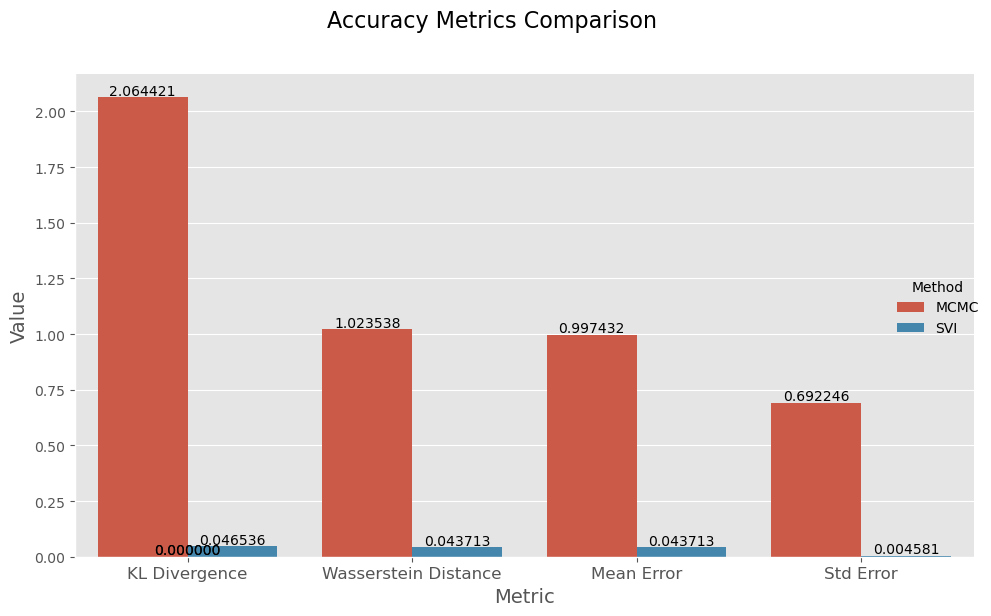

In [ ]:
# Convert metrics to DataFrame for easier plotting
metrics_df = pd.DataFrame([
    {'Metric': 'KL Divergence', 'MCMC': accuracy_metrics['KL Divergence']['MCMC'], 'SVI': accuracy_metrics['KL Divergence']['SVI']},
    {'Metric': 'Wasserstein Distance', 'MCMC': accuracy_metrics['Wasserstein Distance']['MCMC'], 'SVI': accuracy_metrics['Wasserstein Distance']['SVI']},
    {'Metric': 'Mean Error', 'MCMC': accuracy_metrics['Mean Error']['MCMC'], 'SVI': accuracy_metrics['Mean Error']['SVI']},
    {'Metric': 'Std Error', 'MCMC': accuracy_metrics['Std Error']['MCMC'], 'SVI': accuracy_metrics['Std Error']['SVI']},
])

# Melt the DataFrame for easier plotting
melted_df = pd.melt(metrics_df, id_vars=['Metric'], var_name='Method', value_name='Value')

# Create the plot
plt.figure(figsize=(14, 10))
g = sns.catplot(data=melted_df, x='Metric', y='Value', hue='Method', kind='bar', height=6, aspect=1.5)
g.fig.suptitle('Accuracy Metrics Comparison', fontsize=16, y=1.02)
g.set_xticklabels(rotation=0, fontsize=12)
g.set_axis_labels("Metric", "Value", fontsize=14)

# Add value labels on bars
ax = g.facet_axis(0, 0)
for i, p in enumerate(ax.patches):
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 0.01,
            f'{p.get_height():.6f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Confidence Interval Coverage

In [ ]:
def calculate_ci_coverage(true_mean, mcmc_samples, svi_samples, ci_levels=[0.5, 0.8, 0.9, 0.95, 0.99]):
    """Calculate if the true mean is contained in confidence intervals of different levels"""
    results = {}
    
    for ci_level in ci_levels:
        alpha = 1 - ci_level
        lower_percentile = alpha / 2 * 100
        upper_percentile = (1 - alpha / 2) * 100
        
        # MCMC CI
        mcmc_lower = np.percentile(mcmc_samples, lower_percentile)
        mcmc_upper = np.percentile(mcmc_samples, upper_percentile)
        mcmc_contains = mcmc_lower <= true_mean <= mcmc_upper
        
        # SVI CI
        svi_lower = np.percentile(svi_samples, lower_percentile)
        svi_upper = np.percentile(svi_samples, upper_percentile)
        svi_contains = svi_lower <= true_mean <= svi_upper
        
        results[ci_level] = {
            'MCMC': {
                'contains': mcmc_contains,
                'lower': mcmc_lower,
                'upper': mcmc_upper
            },
            'SVI': {
                'contains': svi_contains,
                'lower': svi_lower,
                'upper': svi_upper
            }
        }
    
    return results

# Calculate CI coverage
ci_coverage = calculate_ci_coverage(true_avg, mcmc_means, svi_means)

# Create DataFrame for visualization
ci_data = []
for ci_level, methods in ci_coverage.items():
    for method, details in methods.items():
        ci_data.append({
            'CI Level': f"{ci_level*100:.0f}%",
            'Method': method,
            'Contains True': details['contains'],
            'Lower': details['lower'],
            'Upper': details['upper'],
            'CI Width': details['upper'] - details['lower']
        })

ci_df = pd.DataFrame(ci_data)

# Display the results
display(ci_df)

,CI Level,Method,Contains True,Lower,Upper,CI Width
0,50%,MCMC,False,3.541519,4.479102,0.937582
1,50%,SVI,False,4.904263,5.095489,0.191226
2,80%,MCMC,True,2.903861,4.908182,2.004321
3,80%,SVI,False,4.819206,5.182611,0.363404
4,90%,MCMC,True,2.451029,5.183469,2.732440
5,90%,SVI,True,4.769378,5.235667,0.466288
6,95%,MCMC,True,1.952868,5.438490,3.485622
7,95%,SVI,True,4.725639,5.281260,0.555621
8,99%,MCMC,True,1.126137,5.870553,4.744416
9,99%,SVI,True,4.635775,5.365785,0.730010


## Visualize Confidence Intervals

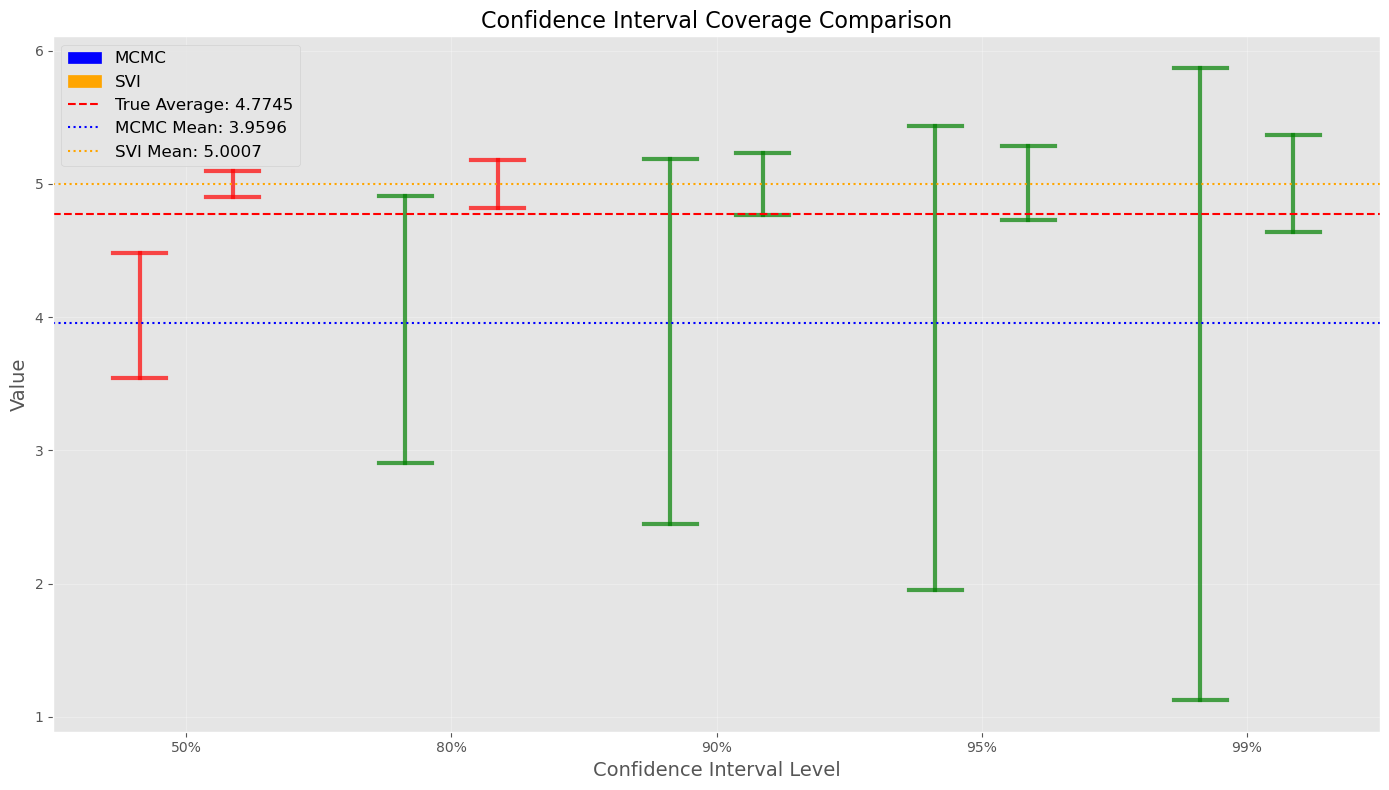

In [ ]:
# Visualize confidence intervals
plt.figure(figsize=(14, 8))

ci_levels = sorted(ci_coverage.keys())
x_positions = np.arange(len(ci_levels))
width = 0.35

# Plot MCMC CIs
for i, ci_level in enumerate(ci_levels):
    mcmc_info = ci_coverage[ci_level]['MCMC']
    color = 'green' if mcmc_info['contains'] else 'red'
    plt.plot([x_positions[i] - width/2, x_positions[i] - width/2], 
             [mcmc_info['lower'], mcmc_info['upper']], 
             color=color, linewidth=3, alpha=0.7)
    plt.plot([x_positions[i] - width/2 - 0.1, x_positions[i] - width/2 + 0.1], 
             [mcmc_info['lower'], mcmc_info['lower']], 
             color=color, linewidth=3, alpha=0.7)
    plt.plot([x_positions[i] - width/2 - 0.1, x_positions[i] - width/2 + 0.1], 
             [mcmc_info['upper'], mcmc_info['upper']], 
             color=color, linewidth=3, alpha=0.7)

# Plot SVI CIs
for i, ci_level in enumerate(ci_levels):
    svi_info = ci_coverage[ci_level]['SVI']
    color = 'green' if svi_info['contains'] else 'red'
    plt.plot([x_positions[i] + width/2, x_positions[i] + width/2], 
             [svi_info['lower'], svi_info['upper']], 
             color=color, linewidth=3, alpha=0.7)
    plt.plot([x_positions[i] + width/2 - 0.1, x_positions[i] + width/2 + 0.1], 
             [svi_info['lower'], svi_info['lower']], 
             color=color, linewidth=3, alpha=0.7)
    plt.plot([x_positions[i] + width/2 - 0.1, x_positions[i] + width/2 + 0.1], 
             [svi_info['upper'], svi_info['upper']], 
             color=color, linewidth=3, alpha=0.7)

# Add true value line
plt.axhline(y=true_avg, color='red', linestyle='--', label=f'True Average: {true_avg:.4f}')

# Add posterior means
plt.axhline(y=mcmc_mean, color='blue', linestyle=':', label=f'MCMC Mean: {mcmc_mean:.4f}')
plt.axhline(y=svi_mean, color='orange', linestyle=':', label=f'SVI Mean: {svi_mean:.4f}')

# Set x-ticks and labels
plt.xticks(x_positions, [f"{ci*100:.0f}%" for ci in ci_levels])
plt.xlabel('Confidence Interval Level', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.title('Confidence Interval Coverage Comparison', fontsize=16)

# Add legend for methods
import matplotlib.patches as mpatches
mcmc_patch = mpatches.Patch(color='blue', label='MCMC')
svi_patch = mpatches.Patch(color='orange', label='SVI')
plt.legend(handles=[mcmc_patch, svi_patch] + plt.gca().get_lines()[-3:], fontsize=12)

plt.grid(True, alpha=0.3)
plt.show()

## Execution Time Comparison

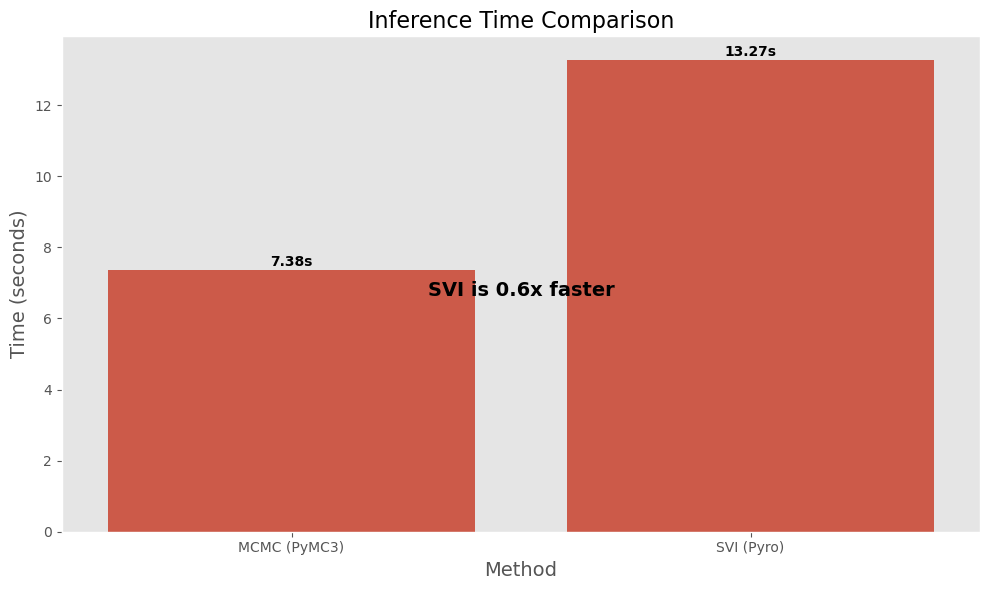

In [ ]:
# Compare inference times
timing_data = pd.DataFrame({
    'Method': ['MCMC (PyMC3)', 'SVI (Pyro)'],
    'Time (seconds)': [mcmc_time, svi_time]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Method', y='Time (seconds)', data=timing_data)
plt.title('Inference Time Comparison', fontsize=16)
plt.ylabel('Time (seconds)', fontsize=14)
plt.xlabel('Method', fontsize=14)
plt.grid(axis='y')

# Add value labels on bars
for i, v in enumerate(timing_data['Time (seconds)']):
    ax.text(i, v + 0.1, f"{v:.2f}s", ha='center', fontweight='bold')

# Add speedup text
speedup = mcmc_time / svi_time
plt.text(0.5, max(timing_data['Time (seconds)']) * 0.5, 
         f"SVI is {speedup:.1f}x faster", 
         ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()